In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    print(col, (df[col]==0).sum())


Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [7]:
#Target Distribution
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

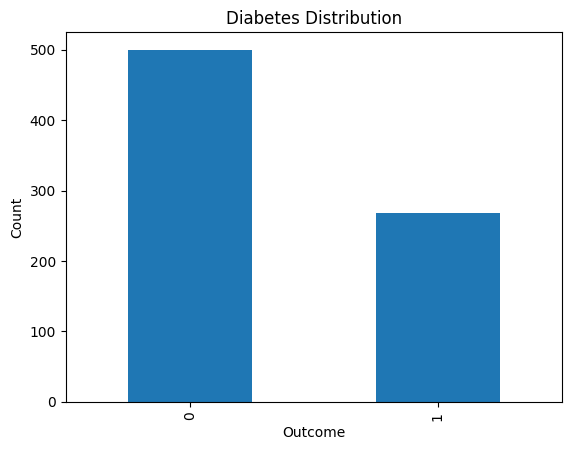

In [8]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Diabetes Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [9]:
#performed exploratory data analysis to understand feature distributions, detect invalid values like zeros, and identify data quality issues before preprocessing.

In [10]:
#Replace 0 with NaN, now zero treated as missing values

In [11]:
df[cols_with_zero]=df[cols_with_zero].replace(0, np.nan)

In [12]:
#Fill Missing Values with Median

#Robust to outliers
#Better than mean for medical data

In [13]:
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15144\2982786776.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [14]:
X=df.drop('Outcome', axis=1)
y=df['Outcome']

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [16]:
#applied scaling after handling missing values and before training models, especially because algorithms like SVM are distance-based.

In [17]:
X_scaled[:5]

array([[ 0.63994726,  0.86462486, -0.03218035,  0.66518138,  0.31160394,
         0.16948251,  0.46849198,  1.4259954 ],
       [-0.84488505, -1.20472661, -0.52812374, -0.01011181, -0.44084303,
        -0.84854874, -0.36506078, -0.19067191],
       [ 1.23388019,  2.01426457, -0.69343821,  0.32753478,  0.31160394,
        -1.32847775,  0.60439732, -0.10558415],
       [-0.84488505, -1.07333922, -0.52812374, -0.685405  , -0.53630272,
        -0.63039919, -0.92076261, -1.04154944],
       [-1.14185152,  0.50330953, -2.67721176,  0.66518138,  0.29475812,
         1.55109634,  5.4849091 , -0.0204964 ]])

In [18]:
from sklearn.model_selection import train_test_split
X_train, y_train, X_test, y_test=train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [19]:
print("X Train:", X_train.shape)
print("X_test:", X_test.shape)

X Train: (614, 8)
X_test: (614,)


In [20]:
#I split the data after preprocessing and used a fixed random_state to ensure reproducibility

In [21]:
train_test_split(X, y, stratify=y)

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 440            0      189          104.0             25    169.5  34.3   
 84             5      137          108.0             32    169.5  48.8   
 388            5      144           82.0             26    285.0  32.0   
 73             4      129           86.0             20    270.0  35.1   
 391            5      166           76.0             32    169.5  45.7   
 ..           ...      ...            ...            ...      ...   ...   
 435            0      141           74.5             32    169.5  42.4   
 666            4      145           82.0             18    169.5  32.5   
 741            3      102           44.0             20     94.0  30.8   
 82             7       83           78.0             26     71.0  29.3   
 730            3      130           78.0             23     79.0  28.4   
 
      DiabetesPedigreeFunction  Age  
 440                     0.435   41  
 84                   

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
def train_logistic_regression(X_train, y_train):
    model=LogisticRegression()
    model.fit(X_train, y_train)

    return model

In [24]:
def predict(model, X_train):
    return model.predict(X_test)

In [25]:
def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [26]:
from sklearn.tree import DecisionTreeClassifier

def train_decision_tree(X_train, y_train):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    return model

In [29]:
def predict(model, X):
    return model.predict(X)


In [30]:
y_pred = model.predict(X_test)

NameError: name 'model' is not defined

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=100,   # number of trees
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

In [ ]:
y_pred_rf = predict(model, X_test)

NameError: name 'model' is not defined